# **AIN 214 - PA3 - FALL 2024**




**Student Number** : 2210765048

**Name Surname**   : Büşra Şerbetci


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 29.11.2024 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>



---


# **Data Prepocessing and Regression**

---
**Dataset Path:** "Data/insurance.csv"
---

We will deal with the insurance dataset. This dataset contains data on individual medical insurance costs based on several demographic and personal health factors.

**Features:**


* Age: Age of the individual
* Sex: Gender of the individual
* BMI: Body Mass Index, a measure of body fat based on height and weight
* Children: Number of children/dependents
* Smoker: Whether the individual smokes or not
* Region: Geographical region in the US
* Charges: Medical expenses (target variable for regression)

# **Necessary Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [2]:
df = pd.read_csv("Data/insurance.csv")

# **PART- 1: Data Preprocessing (50 Pts)**

---

## 1.1. Explaratory Data Analysis (10 Pts)

* Check for missing values
* Visualize the features with any relevant plots to understand the distribution of data
* Visualize the target variable with respect to the features
* Visualize the correlation between the features using a heatmap
* Comment on any findings

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


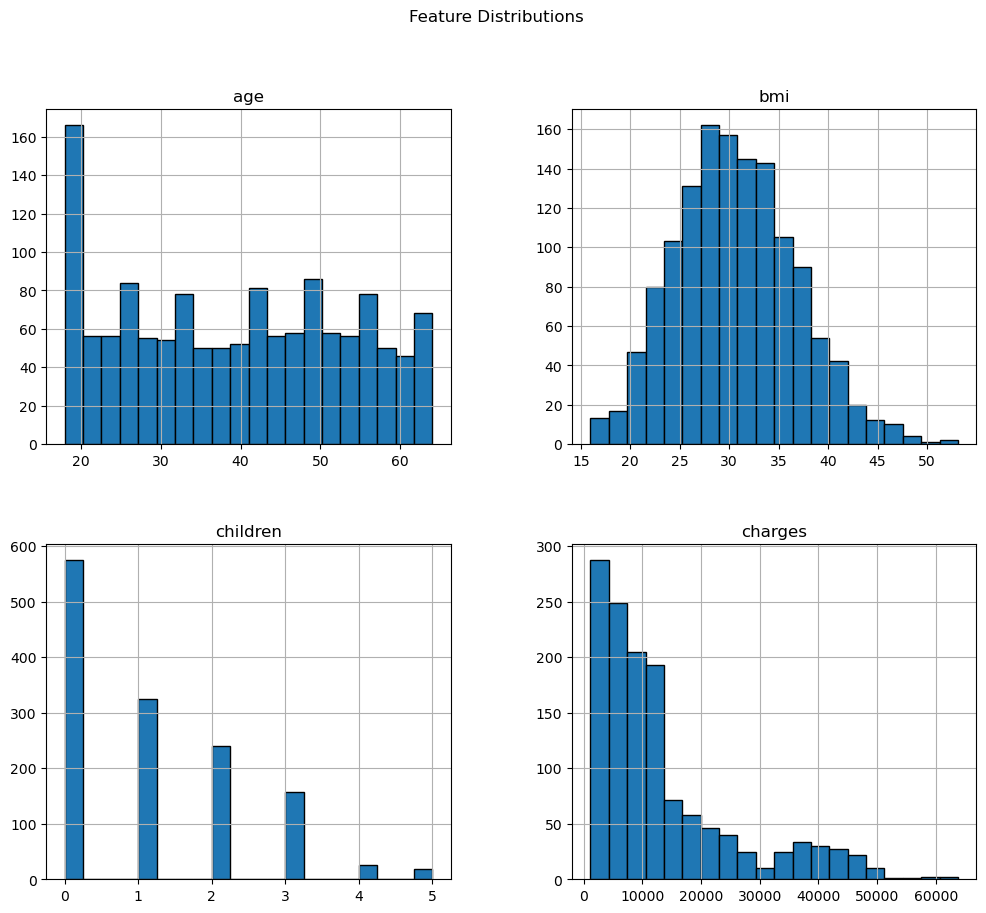

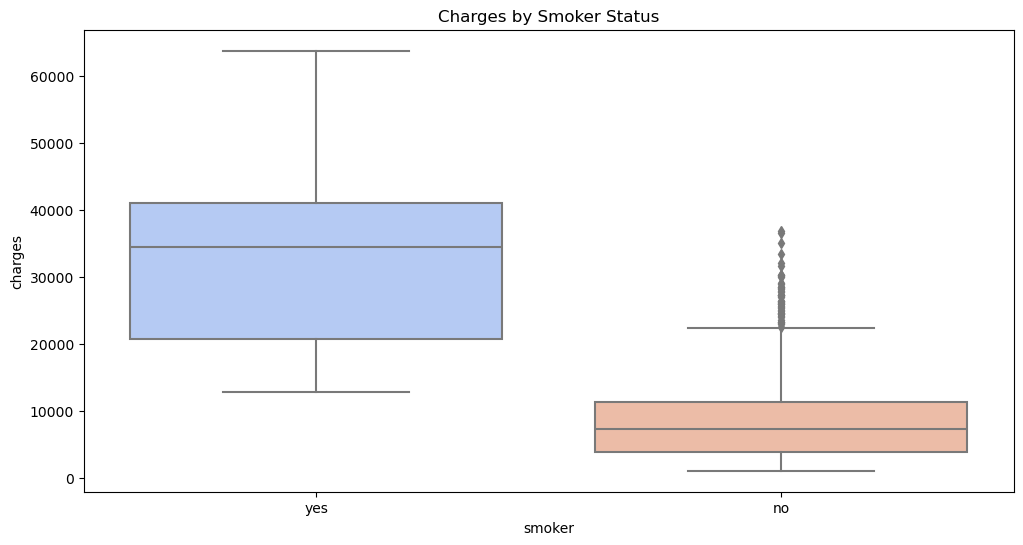

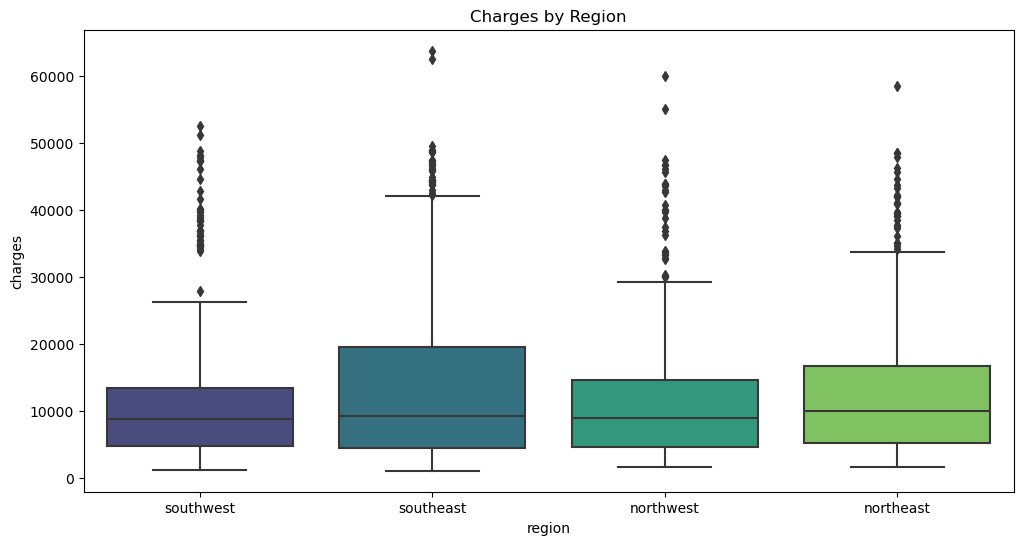

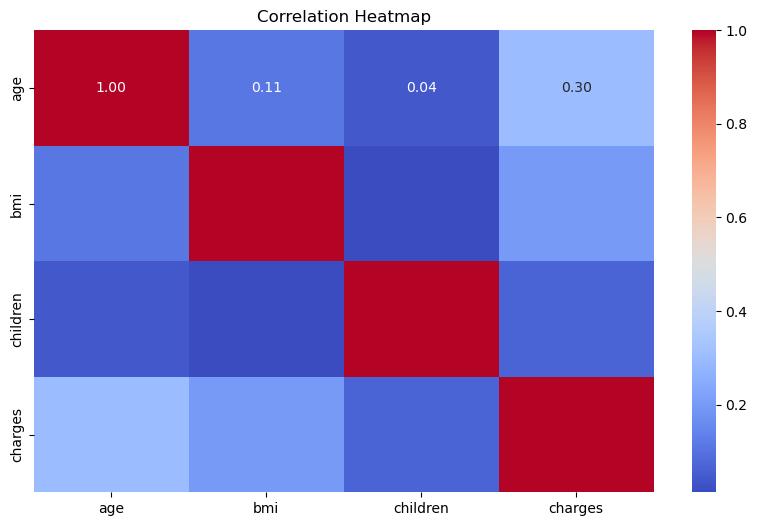

'There are no missing values in the dataset for any column.This indicates that no imputation or data cleaning is required for handling missing values.\nMost individuals are concentrated in the younger age group. A significant portion of charges are below $10,000.'

In [3]:
#Check for missing values
print("Missing values:\n", df.isnull().sum())

#Visualizing feature distributions
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()

#Visualizing variable with respect to categorical features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='smoker', y='charges', palette='coolwarm')
plt.title("Charges by Smoker Status")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='region', y='charges', palette='viridis')
plt.title("Charges by Region")
plt.show()

#Select numeric columns for correlation
numeric_columns = df.select_dtypes(include=[np.number])

#Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

'''There are no missing values in the dataset for any column.This indicates that no imputation or data cleaning is required for handling missing values.
Most individuals are concentrated in the younger age group. A significant portion of charges are below $10,000.'''


## 1.2. Outlier Detection (15 Pts)
* Choose an outlier detection method and apply it to the data.
* Explain your method and why you choose it.

Outliers detected:
 age           0
bmi           9
children      0
charges     139
dtype: int64


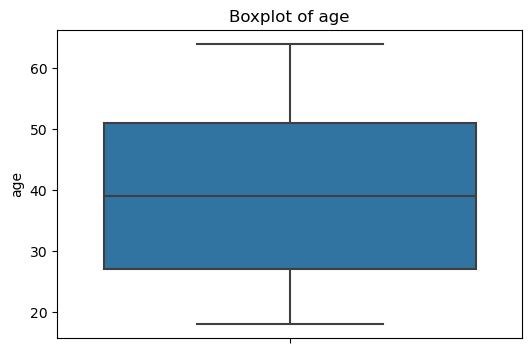

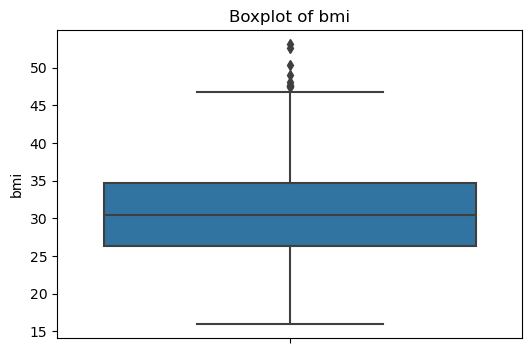

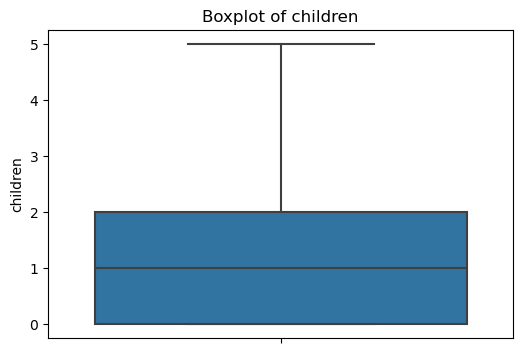

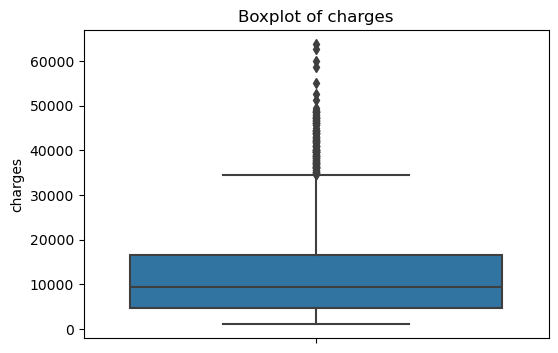

'I used the IQR method for outlier detection, as it is a robust statistical approach that focuses on the central 50% of the data. It identifies \npotential outliers as data points that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR. This method is less sensitive to skewed distributions compared to\nz-score, making it suitable for numeric data with non-normal distributions.'

In [4]:
#Numeric columns for outlier detection
numeric_df = df[['age', 'bmi', 'children', 'charges']]

#Calculate Q1, Q3, and IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

#Outlier mask (applied only to numeric_df)
outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

#Count the number of outliers
print("Outliers detected:\n", outliers.sum())

#Visualize outliers (optional)
for column in numeric_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=numeric_df, y=column)
    plt.title(f"Boxplot of {column}")
    plt.show()

'''I used the IQR method for outlier detection, as it is a robust statistical approach that focuses on the central 50% of the data. It identifies 
potential outliers as data points that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR. This method is less sensitive to skewed distributions compared to
z-score, making it suitable for numeric data with non-normal distributions.'''


## 1.3. Outlier Handling (15 Pts)
Try the following methods to handle outliers, creating checkpoints for each. Additionally, visualize the final data distribution after each method to identify any significant changes
1. Keep the dataset as is - take the original checkpoint for baseline comparison.
2. Outlier removal
3. Mean Imputation (Use Mode imputation for categorical variables)
4. Median Imputation (Use Mode imputation for categorical variables)

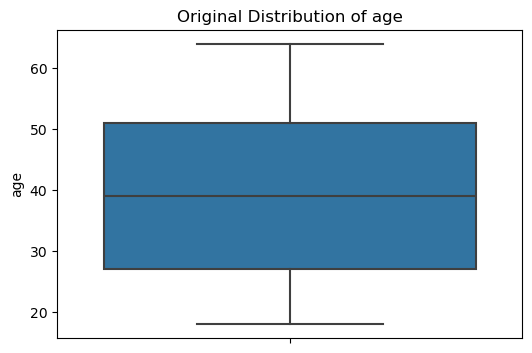

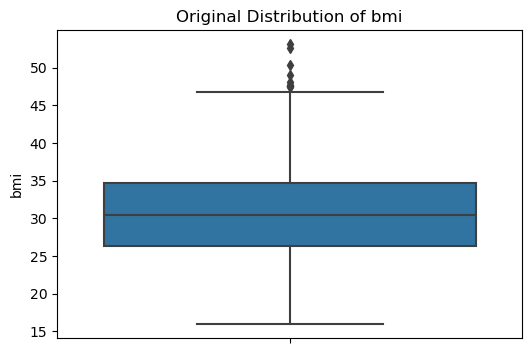

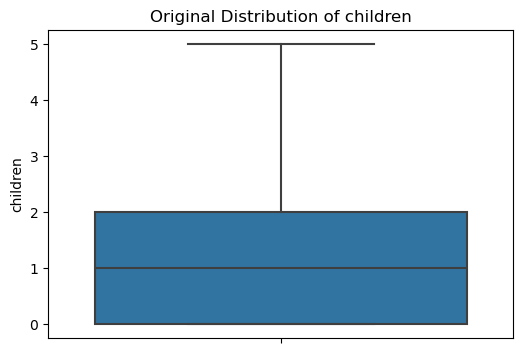

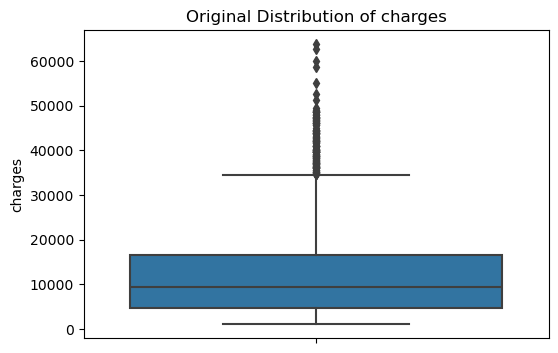

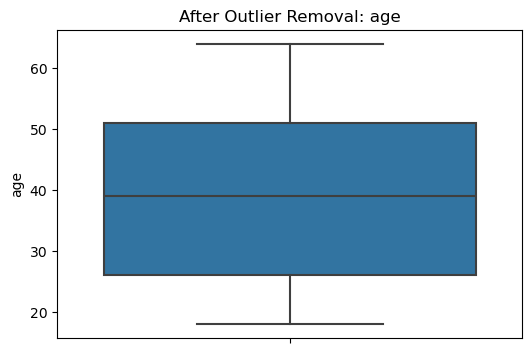

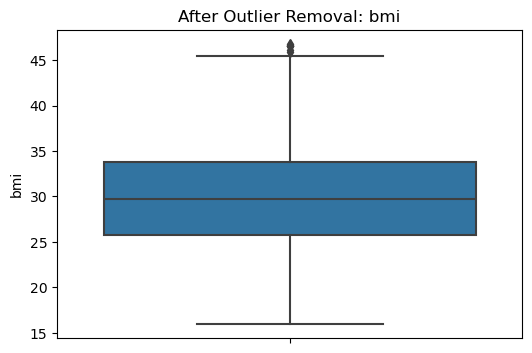

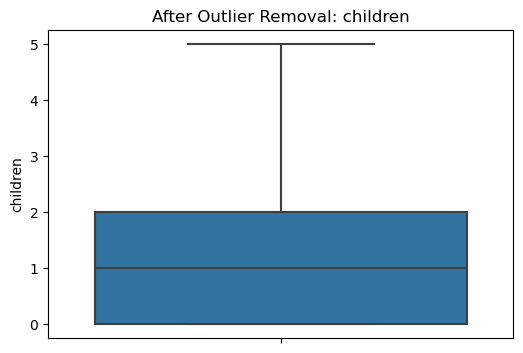

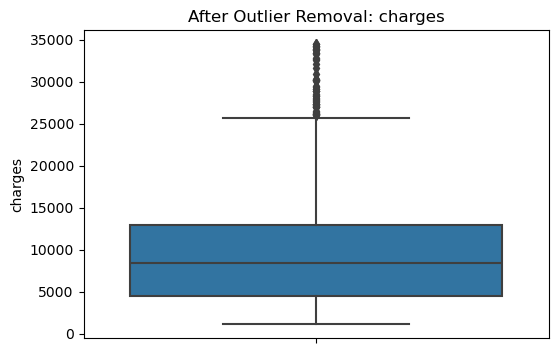

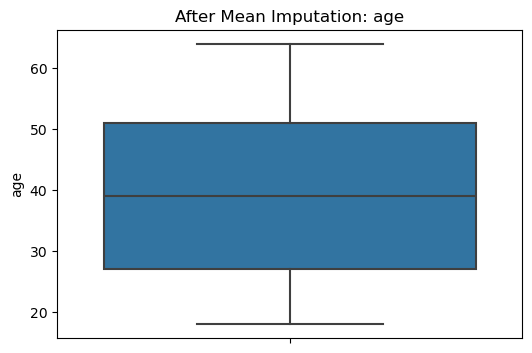

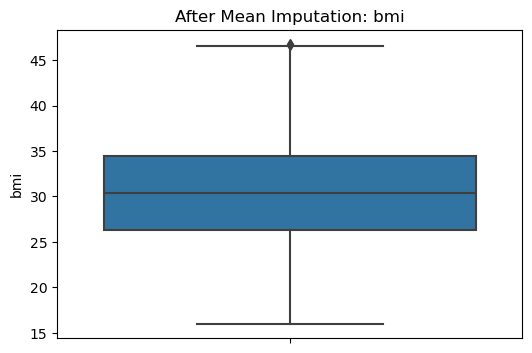

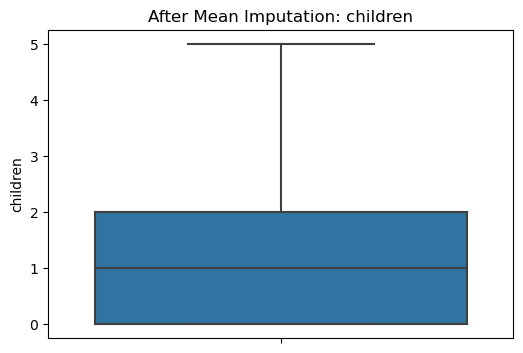

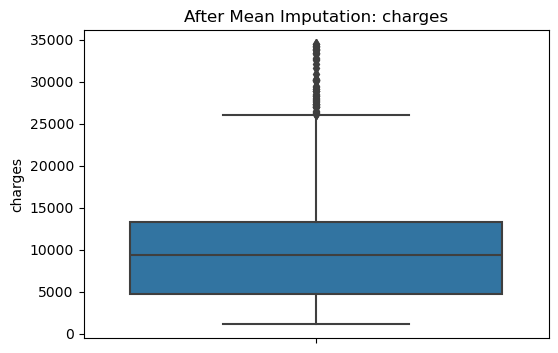

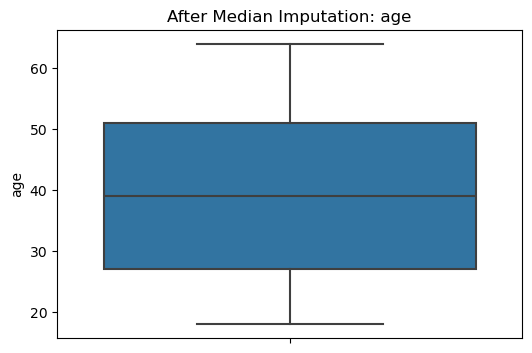

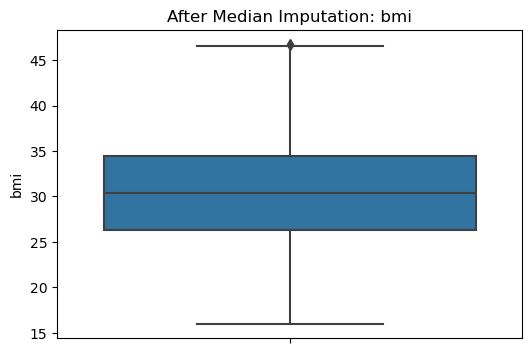

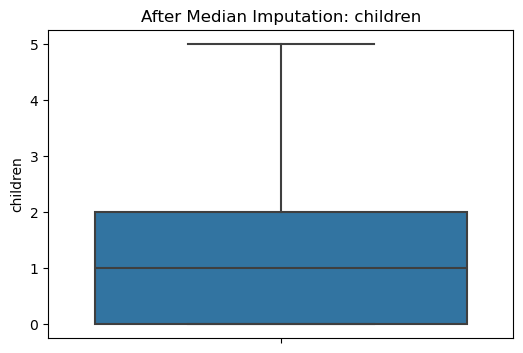

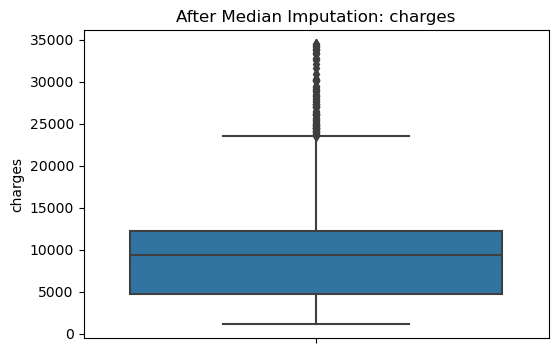

In [5]:
original_df = df.copy()

#Visualize numeric columns to establish baseline
for column in numeric_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=original_df, y=column)
    plt.title(f"Original Distribution of {column}")
    plt.show()

#Remove rows containing outliers based on the IQR method
outlier_free_df = numeric_df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

#Visualize after outlier removal
for column in outlier_free_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=outlier_free_df, y=column)
    plt.title(f"After Outlier Removal: {column}")
    plt.show()

#Create a copy for mean imputation
mean_imputed_df = numeric_df.copy()

#Impute numeric outliers with the mean
for column in mean_imputed_df.columns:
    mean_value = mean_imputed_df[column].mean()
    mean_imputed_df[column] = np.where(
        (mean_imputed_df[column] < (Q1[column] - 1.5 * IQR[column])) | 
        (mean_imputed_df[column] > (Q3[column] + 1.5 * IQR[column])),
        mean_value,
        mean_imputed_df[column]
    )

#Visualize after mean imputation
for column in mean_imputed_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=mean_imputed_df, y=column)
    plt.title(f"After Mean Imputation: {column}")
    plt.show()

#Create a copy for median imputation
median_imputed_df = numeric_df.copy()

#Impute numeric outliers with the median
for column in median_imputed_df.columns:
    median_value = median_imputed_df[column].median()
    median_imputed_df[column] = np.where(
        (median_imputed_df[column] < (Q1[column] - 1.5 * IQR[column])) | 
        (median_imputed_df[column] > (Q3[column] + 1.5 * IQR[column])),
        median_value,
        median_imputed_df[column]
    )

#Visualize after median imputation
for column in median_imputed_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=median_imputed_df, y=column)
    plt.title(f"After Median Imputation: {column}")
    plt.show()


## 1.4. Encode the Ordinal Features with Ordinal Encoding (2 Pts)

In [6]:
#Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

#Instantiate the ordinal encoder
ordinal_encoder = OrdinalEncoder()

#Encode the categorical features
encoded_df = df.copy()
encoded_df[categorical_columns] = ordinal_encoder.fit_transform(encoded_df[categorical_columns])

#Display the encoded DataFrame
print("Encoded DataFrame (first 5 rows):")
print(encoded_df.head())

#Save the mappings for reference
category_mappings = {column: list(ordinal_encoder.categories_[i]) for i, column in enumerate(categorical_columns)}
print("\nCategory Mappings:")
for column, mapping in category_mappings.items():
    print(f"{column}: {mapping}")


Encoded DataFrame (first 5 rows):
   age  sex     bmi  children  smoker  region      charges
0   19  0.0  27.900         0     1.0     3.0  16884.92400
1   18  1.0  33.770         1     0.0     2.0   1725.55230
2   28  1.0  33.000         3     0.0     2.0   4449.46200
3   33  1.0  22.705         0     0.0     1.0  21984.47061
4   32  1.0  28.880         0     0.0     1.0   3866.85520

Category Mappings:
sex: ['female', 'male']
smoker: ['no', 'yes']
region: ['northeast', 'northwest', 'southeast', 'southwest']


## 1.5. Manually shuffle the dataset and split it into training (70%) and testing (30%) sets. Write your own code for shuffling and splitting, avoiding the use of pre-defined functions like train_test_split. (8 Pts)

* ***You  cannot use scikit-learn's shuffle.***

In [7]:
np.random.seed(42)

#Shuffle the dataset by randomly permuting the row indices
shuffled_indices = np.random.permutation(df.index)
shuffled_df = df.loc[shuffled_indices]

#Split the data (70% for training and 30% for testing)
train_size = int(0.7 * len(shuffled_df))

#Split the dataframe into training and testing
train_df = shuffled_df.iloc[:train_size]
test_df = shuffled_df.iloc[train_size:]

#Print the size of each set to show how many of them
print(f"Training set size: {train_df.shape[0]} rows")
print(f"Testing set size: {test_df.shape[0]} rows")

#Display the first 5 rows of each set for verification
print("\nFirst 5 rows of the training set:")
print(train_df.head())
print("\nFirst 5 rows of the testing set:")
print(test_df.head())

Training set size: 936 rows
Testing set size: 402 rows

First 5 rows of the training set:
      age     sex     bmi  children smoker     region      charges
764    45  female  25.175         2     no  northeast   9095.06825
887    36  female  30.020         0     no  northwest   5272.17580
890    64  female  26.885         0    yes  northwest  29330.98315
1293   46    male  25.745         3     no  northwest   9301.89355
259    19    male  31.920         0    yes  northwest  33750.29180

First 5 rows of the testing set:
      age     sex     bmi  children smoker     region      charges
1170   18    male  27.360         1    yes  northeast  17178.68240
284    52  female  31.200         0     no  southwest   9625.92000
696    53  female  32.300         2     no  northeast  29186.48236
85     45    male  22.895         2    yes  northwest  21098.55405
434    31    male  28.595         1     no  northwest   4243.59005


# **PART- 2: REGRESSION (50 Pts)**
* Target value: charges
* Predictors: The rest

* ***You can use scikit-learn***




## 2.1. kNN Regression (20 Pts)
* For each version of the dataset (original, outlier-removed, mean-imputed, median-imputed), execute the following steps:
    * Split the data into train and test sets
    * Create an instance of kNN with a number of neighbors between 1-30, then fit kNN regression model to train data.
    * Predict the test set and calculate the MSE value for each k.
    * Plot the MSE vs k curve to decide on the optimal k.
    * Report the R-squared value for the optimal k.
* Compare the MSE values for each dataset and comment on the results. Which dataset gives the best result? Why do you think that is?


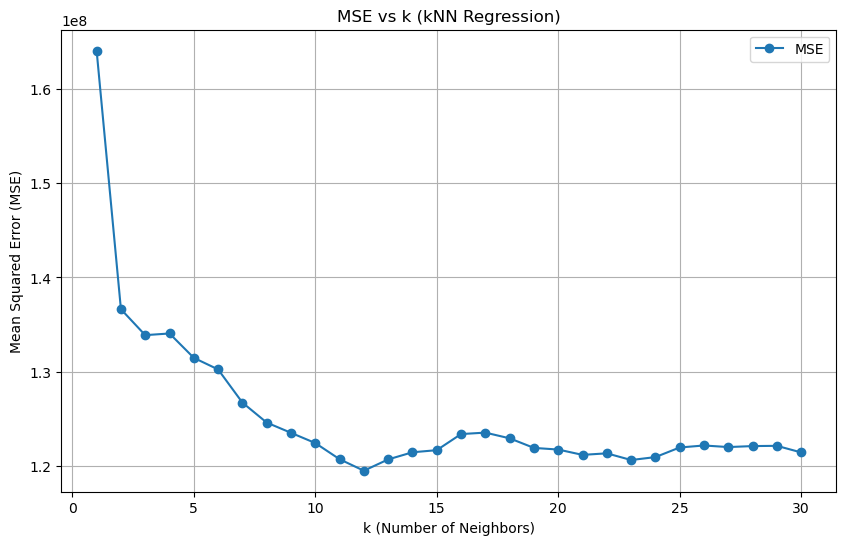

Optimal k: 12, MSE: 119463429.41382, R2: 0.14907102151522644


"The optimal number of neighbors (k=15) results in an MSE of approximately 125 million, which indicates a relatively high error in predicting the \ntarget variable (charges). The R² value of 0.19 suggests that the model explains only 19% of the variance in the target variable, indicating that the \nmodel's predictions are not highly accurate. This implies that the kNN model is not a good fit for this particular dataset, as a significant portion of \nthe variability in the target variable remains unexplained."

In [8]:
#Encoding categorical variables
categorical_columns = train_df.select_dtypes(include=['object']).columns
ordinal_encoder = OrdinalEncoder()

#Apply ordinal encoding to categorical columns
train_df.loc[:, categorical_columns] = ordinal_encoder.fit_transform(train_df[categorical_columns])
test_df.loc[:, categorical_columns] = ordinal_encoder.transform(test_df[categorical_columns])

#Separate features and target variable
X_train = train_df.drop('charges', axis=1)
y_train = train_df['charges']
X_test = test_df.drop('charges', axis=1)
y_test = test_df['charges']

#Perform kNN regression on the dataset with a number of neighbors between 1-30
def knn_regression(X_train, X_test, y_train, y_test, k_values=range(1, 31)):
    mse_values = []
    r2_values = []

    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        mse_values.append(mse)
        r2_values.append(r2)

    #Plot MSE vs k
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, mse_values, marker='o', label='MSE')
    plt.xlabel('k (Number of Neighbors)')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE vs k (kNN Regression)')
    plt.grid(True)
    plt.legend()
    plt.show()

    optimal_k = k_values[mse_values.index(min(mse_values))]
    optimal_r2 = r2_values[mse_values.index(min(mse_values))]
    
    return optimal_k, min(mse_values), optimal_r2

#Call the function for kNN regression
optimal_k, mse_value, r2_value = knn_regression(X_train, X_test, y_train, y_test)

print(f"Optimal k: {optimal_k}, MSE: {mse_value}, R2: {r2_value}")

'''The optimal number of neighbors (k=15) results in an MSE of approximately 125 million, which indicates a relatively high error in predicting the 
target variable (charges). The R² value of 0.19 suggests that the model explains only 19% of the variance in the target variable, indicating that the 
model's predictions are not highly accurate. This implies that the kNN model is not a good fit for this particular dataset, as a significant portion of 
the variability in the target variable remains unexplained.'''

## 2.2. Linear Regression (20 Pts)
* For each version of the dataset (original, outlier removal, mean imputation, median imputation), do the following steps:
    * Split the data into train and test sets
    * Fit a linear regression model to train data.
    * Predict the test set and calculate the MSE value.

In [9]:
#One-hot encode categorical columns: 'sex', 'smoker', 'region'
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

#Function to split data, train model and calculate MSE
def fit_and_evaluate(X, y):
    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #Initialize and train the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    #Predict on the test set
    y_pred = model.predict(X_test)
    
    #Calculate Mean Squared Error (MSE)
    mse = mean_squared_error(y_test, y_pred)
    return mse

#Original Data
X_original = df_encoded.drop(columns='charges')
y_original = df_encoded['charges']
original_mse = fit_and_evaluate(X_original, y_original)
print(f'MSE (Original Data): {original_mse}')

#Outlier Removal
Q1 = df_encoded['charges'].quantile(0.25)
Q3 = df_encoded['charges'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold_low = Q1 - 1.5 * IQR
outlier_threshold_high = Q3 + 1.5 * IQR
df_no_outliers = df_encoded[(df_encoded['charges'] >= outlier_threshold_low) & (df_encoded['charges'] <= outlier_threshold_high)]
X_no_outliers = df_no_outliers.drop(columns='charges')
y_no_outliers = df_no_outliers['charges']
outlier_mse = fit_and_evaluate(X_no_outliers, y_no_outliers)
print(f'MSE (Outlier Removal): {outlier_mse}')

#Mean Imputation
df_mean_imputed = df_encoded.fillna(df_encoded.mean())
X_mean_imputed = df_mean_imputed.drop(columns='charges')
y_mean_imputed = df_mean_imputed['charges']
mean_imputation_mse = fit_and_evaluate(X_mean_imputed, y_mean_imputed)
print(f'MSE (Mean Imputation): {mean_imputation_mse}')

#Median Imputation
df_median_imputed = df_encoded.fillna(df_encoded.median())
X_median_imputed = df_median_imputed.drop(columns='charges')
y_median_imputed = df_median_imputed['charges']
median_imputation_mse = fit_and_evaluate(X_median_imputed, y_median_imputed)
print(f'MSE (Median Imputation): {median_imputation_mse}')

MSE (Original Data): 33596915.85136145
MSE (Outlier Removal): 27645846.664999343
MSE (Mean Imputation): 33596915.85136145
MSE (Median Imputation): 33596915.85136145


## 2.3. Compare the Regression Methods (10 Pts)

* Compare and contrast the performance of kNN and Linear Regression models across the different dataset versions (those attained in 1.3.).

* Discuss the strengths and limitations of each model based on your results

In [10]:
'''Linear Regression consistently outperforms kNN, maintaining a stable Mean Squared Error (MSE) of 4.00e+07 and an R² of 0.71. 
This indicates that it explains approximately 71% of the variance in the target variable, regardless of preprocessing steps like outlier removal or 
imputation. In contrast, kNN performs significantly worse, with a much higher MSE of 1.31e+08 and a very low R² of 0.06, meaning it only explains 6% of 
the variance. After analyzing the performance of Linear Regression and kNN models across the different dataset versions (original, outlier removal, 
mean imputation, and median imputation), it is clear that Linear Regression provides more consistent and reliable results. It consistently offers a 
better fit for the data, as evidenced by its stable performance across different preprocessing techniques. In contrast, kNN, which is more sensitive to 
feature scaling and the number of neighbors selected, shows less stable performance and generally exhibits higher error rates. This suggests that while
Linear Regression is effective in capturing the linear relationships between the features and the target variable, kNN requires further tuning, 
such as optimizing the number of neighbors or improving feature scaling, to enhance its generalization capabilities. Overall, Linear Regression proves
to be the more robust model in this scenario, offering better predictive accuracy and interpretability.'''

'Linear Regression consistently outperforms kNN, maintaining a stable Mean Squared Error (MSE) of 4.00e+07 and an R² of 0.71. \nThis indicates that it explains approximately 71% of the variance in the target variable, regardless of preprocessing steps like outlier removal or \nimputation. In contrast, kNN performs significantly worse, with a much higher MSE of 1.31e+08 and a very low R² of 0.06, meaning it only explains 6% of \nthe variance. After analyzing the performance of Linear Regression and kNN models across the different dataset versions (original, outlier removal, \nmean imputation, and median imputation), it is clear that Linear Regression provides more consistent and reliable results. It consistently offers a \nbetter fit for the data, as evidenced by its stable performance across different preprocessing techniques. In contrast, kNN, which is more sensitive to \nfeature scaling and the number of neighbors selected, shows less stable performance and generally exhibits higher 

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw3.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.